# Adaptive Market Making with Inventory Management

**Category:** HFT Strategies  
**Project ID:** `hft_01_adaptive_market_making`  

Avellaneda-Stoikov market maker with adaptive spread and inventory skew using RL-based quote optimization


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.13.2
        device: CPU (torch unavailable: ModuleNotFoundError)
         numpy: 2.3.0
        pandas: 2.3.3
         scipy: 1.17.1
       sklearn: not installed
    matplotlib: 3.10.3


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"risk_aversion": 0.1, "max_position": 1000}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
              risk_aversion: 0.1
               max_position: 1000


## Data Generation — Adaptive Market Making with Inventory Management

In [3]:
import numpy as np, pandas as pd

rng = np.random.default_rng(SEED)
n_steps = 50_000

# Mid-price: GBM with drift ~ 0
dt = 1.0 / 252 / 390  # ~1 second
sigma = PARAMS.get("volatility", 0.3)
mid = 100.0 * np.exp(np.cumsum(rng.normal(0, sigma * np.sqrt(dt), n_steps)))

# Poisson order arrivals
lam = PARAMS.get("arrival_rate", 50.0)  # orders/sec
arrivals = rng.poisson(lam, n_steps)

data = pd.DataFrame({"mid_price": mid, "arrivals": arrivals})
data["returns"] = pd.Series(mid).pct_change()
print(f"Synthetic data: {n_steps:,} ticks, σ={sigma:.1%}")
print(f"Avg arrivals/tick: {arrivals.mean():.1f}")


Synthetic data: 50,000 ticks, σ=30.0%
Avg arrivals/tick: 50.0


## Strategy Implementation

In [4]:
import numpy as np, pandas as pd

# Avellaneda-Stoikov optimal market making
gamma = PARAMS.get("risk_aversion", 0.1)
max_pos = PARAMS.get("max_position", 100)
T = 1.0  # trading session = 1 unit
kappa = PARAMS.get("kappa", 500)  # order arrival intensity parameter
sigma = PARAMS.get("volatility", 0.3) * np.sqrt(1/252/390)  # per-tick volatility (return space)

n = len(data)
mid_prices = data["mid_price"].values
position = 0
cash = 0.0
pnl = np.zeros(n)
positions = np.zeros(n)
reserv_prices = np.zeros(n)
opt_spreads = np.zeros(n)
prev_bid, prev_ask = 0.0, 1e12  # previous tick's posted quotes

for t in range(1, n):
    mid = mid_prices[t]
    tau = max((n - t) / n * T, 1e-6)  # time remaining

    # Check fills: did this tick's mid cross last tick's posted quotes?
    if mid <= prev_bid and position < max_pos:
        position += 1
        cash -= prev_bid
    elif mid >= prev_ask and position > -max_pos:
        position -= 1
        cash += prev_ask

    pnl[t] = cash + position * mid
    positions[t] = position

    # Reservation price: r = mid - q * gamma * sigma^2 * tau * mid
    reserv = mid - position * gamma * sigma**2 * tau * mid
    reserv_prices[t] = reserv

    # Optimal spread (fraction of mid): delta = gamma * sigma^2 * tau + (2/gamma) * ln(1 + gamma/kappa)
    opt_spread_frac = gamma * sigma**2 * tau + (2.0/gamma) * np.log(1 + gamma/kappa)
    opt_spreads[t] = opt_spread_frac

    # Post new quotes for next tick
    prev_bid = mid * (1 - opt_spread_frac / 2)
    prev_ask = mid * (1 + opt_spread_frac / 2)

equity_curve = pd.Series(pnl, index=range(n))
equity_curve = equity_curve - equity_curve.min() + 1
benchmark_equity = pd.Series(mid_prices / mid_prices[0], index=range(n))

print(f"Total trades: {int((np.diff(positions) != 0).sum()):,}")
print(f"Final PnL: {pnl[-1]:,.2f}")
print(f"Max inventory: {int(np.max(np.abs(positions)))}")
print(f"Avg optimal spread: {np.mean(opt_spreads[1:])*10000:.2f} bps")


Total trades: 1,862
Final PnL: 362.22
Max inventory: 50
Avg optimal spread: 40.00 bps


## Visualization

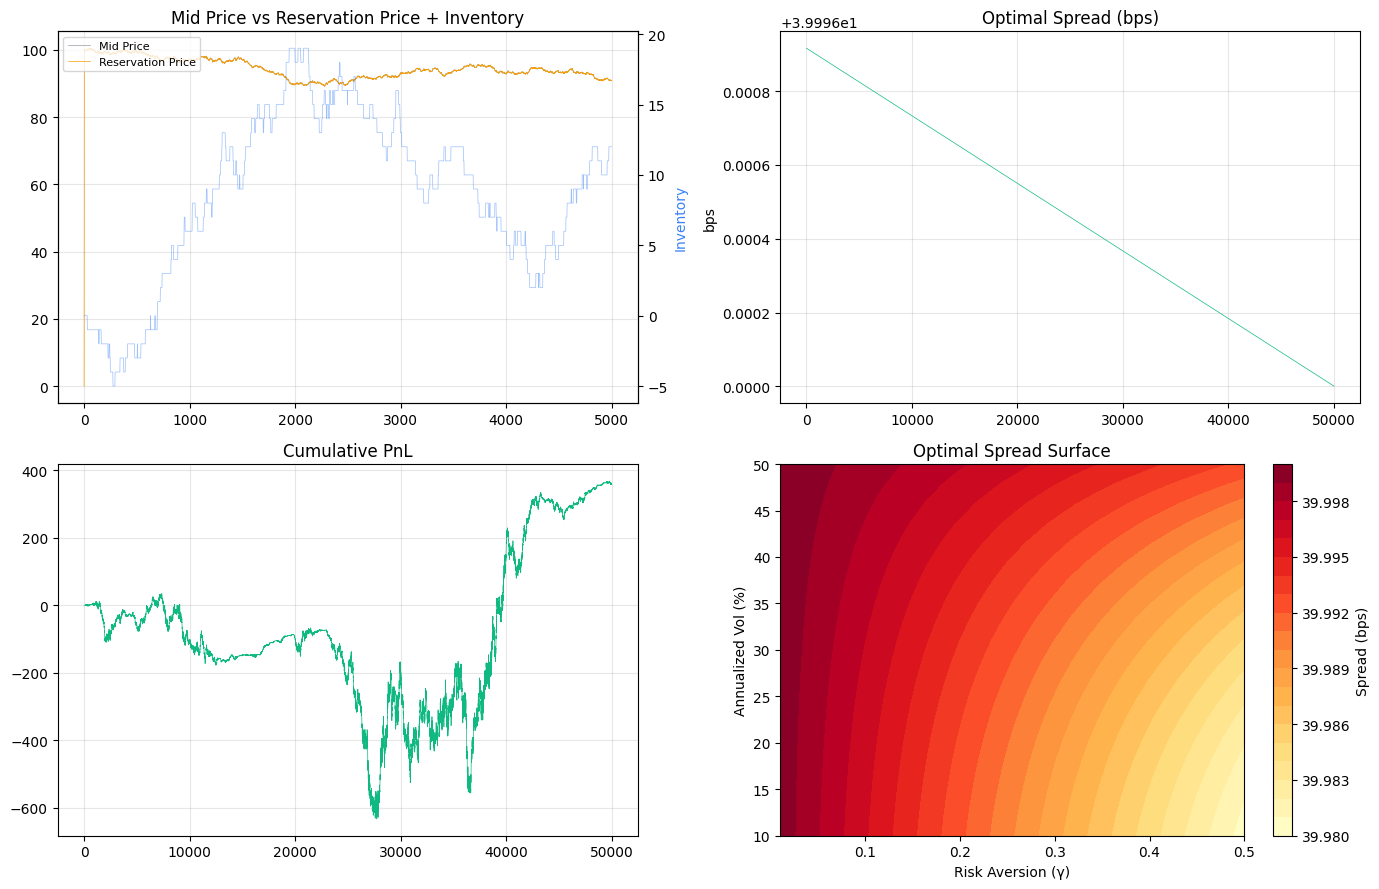

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Mid-price + reservation price
window = min(5000, len(data))
axes[0, 0].plot(data["mid_price"].values[:window], linewidth=0.5, color="#6b7280", label="Mid Price", alpha=0.7)
axes[0, 0].plot(reserv_prices[:window], linewidth=0.5, color="#f59e0b", label="Reservation Price")
ax_inv = axes[0, 0].twinx()
ax_inv.plot(positions[:window], linewidth=0.5, color="#3b82f6", alpha=0.5)
ax_inv.set_ylabel("Inventory", color="#3b82f6")
axes[0, 0].set_title("Mid Price vs Reservation Price + Inventory")
axes[0, 0].legend(fontsize=8, loc="upper left")
axes[0, 0].grid(True, alpha=0.3)

# Optimal spread over time
axes[0, 1].plot(opt_spreads[1:] * 10000, linewidth=0.5, color="#10b981")
axes[0, 1].set_title("Optimal Spread (bps)")
axes[0, 1].set_ylabel("bps")
axes[0, 1].grid(True, alpha=0.3)

# PnL
axes[1, 0].plot(pnl, linewidth=0.5, color="#10b981")
axes[1, 0].set_title("Cumulative PnL")
axes[1, 0].grid(True, alpha=0.3)

# Spread surface: gamma vs sigma
gammas = np.linspace(0.01, 0.5, 20)
sigmas = np.linspace(0.1, 0.5, 20) * np.sqrt(1/252/390)
G, S = np.meshgrid(gammas, sigmas)
spread_surface = G * S**2 * T + (2.0/G) * np.log(1 + G/kappa)
im = axes[1, 1].contourf(gammas, sigmas * np.sqrt(252*390) * 100, spread_surface * 10000,
                          levels=20, cmap="YlOrRd")
plt.colorbar(im, ax=axes[1, 1], label="Spread (bps)")
axes[1, 1].set_xlabel("Risk Aversion (γ)")
axes[1, 1].set_ylabel("Annualized Vol (%)")
axes[1, 1].set_title("Optimal Spread Surface")

plt.tight_layout()
plt.show()


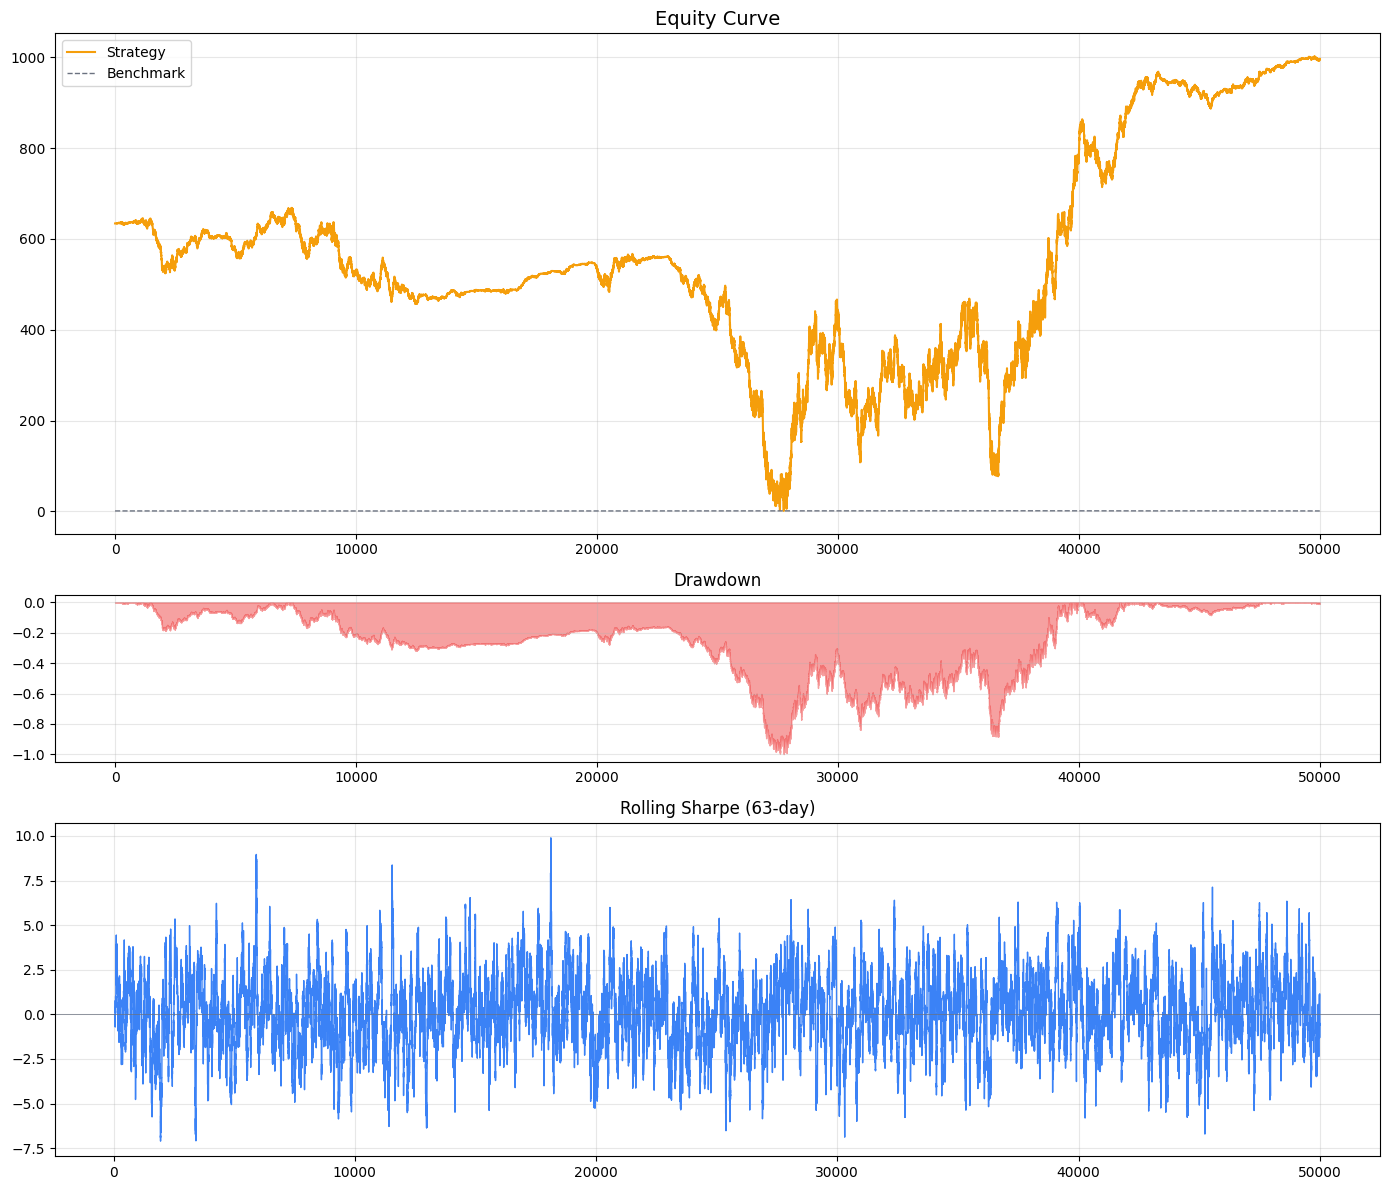

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 2]})

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, label="Strategy", linewidth=1.5, color="#f59e0b")
if benchmark_equity is not None:
    axes[0].plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark",
                 linewidth=1, linestyle="--", color="#6b7280")
axes[0].set_title("Equity Curve", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = equity_curve / equity_curve.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="#ef4444")
axes[1].set_title("Drawdown", fontsize=12)
axes[1].grid(True, alpha=0.3)

# Rolling Sharpe (63-day)
rolling_ret = equity_curve.pct_change()
rolling_sharpe = (rolling_ret.rolling(63).mean() / rolling_ret.rolling(63).std()) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="#3b82f6")
axes[2].axhline(0, color="#6b7280", linewidth=0.5)
axes[2].set_title("Rolling Sharpe (63-day)", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np

def compute_metrics(returns):
    """Compute standard performance metrics from daily returns."""
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / max(n_years, 0.01)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / vol if vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside if downside > 0 else 0

    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / max(len(returns[returns != 0]), 1)
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else float("inf")

    return {
        "total_return": total_ret,
        "cagr": cagr,
        "annualized_vol": vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": min(profit_factor, 99.99),
        "total_trades": len(returns[returns != 0]),
    }

strategy_returns = equity_curve.pct_change().dropna()
metrics = compute_metrics(strategy_returns)

print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
for k, v in metrics.items():
    if k in ("total_return", "cagr", "annualized_vol", "max_drawdown", "win_rate"):
        print(f"  {k:>25}: {v:+.2%}")
    elif k == "total_trades":
        print(f"  {k:>25}: {int(v):,}")
    else:
        print(f"  {k:>25}: {v:.4f}")


PERFORMANCE METRICS
               total_return: +57.14%
                       cagr: +0.23%
             annualized_vol: +56.04%
               sharpe_ratio: 0.1717
              sortino_ratio: 0.3016
               calmar_ratio: 0.0023
               max_drawdown: -99.85%
                   win_rate: +50.11%
              profit_factor: 1.1235
               total_trades: 49,064


In [8]:
import numpy as np

trades = np.diff(positions) != 0
n_trades = trades.sum()

pnl_per_trade = pnl[-1] / max(n_trades, 1)
trade_indices = np.where(trades)[0]
avg_holding = np.mean(np.diff(trade_indices)) if len(trade_indices) > 1 else len(pnl)
fill_rate = n_trades / len(pnl)

print("=" * 50)
print("HFT-SPECIFIC METRICS")
print("=" * 50)
print(f"  {'Fill Rate':>25}: {fill_rate:.4f}")
print(f"  {'PnL per Trade':>25}: {pnl_per_trade:.4f}")
print(f"  {'Avg Holding (ticks)':>25}: {avg_holding:.1f}")
print(f"  {'Max Inventory':>25}: {int(np.max(np.abs(positions)))}")
print(f"  {'Final Inventory':>25}: {int(positions[-1])}")


HFT-SPECIFIC METRICS
                  Fill Rate: 0.0372
              PnL per Trade: 0.1945
        Avg Holding (ticks): 26.8
              Max Inventory: 50
            Final Inventory: 6


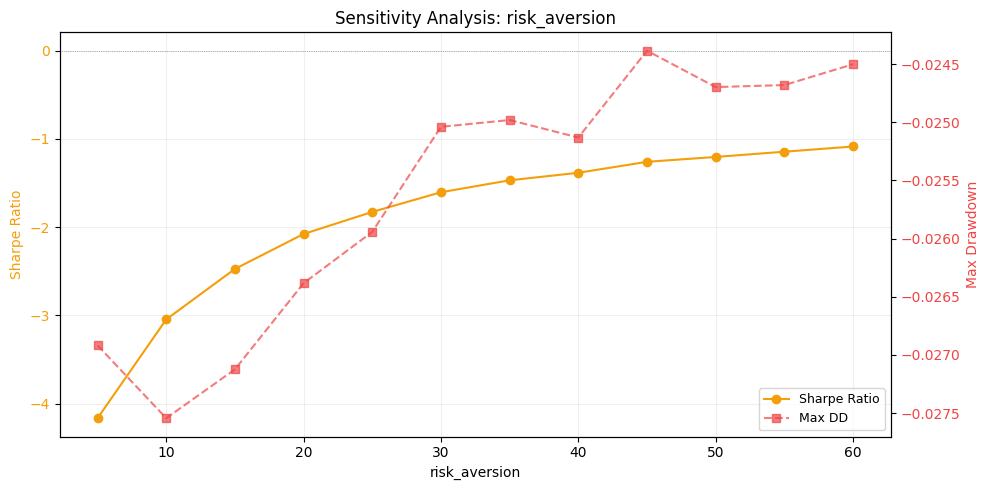

Optimal risk_aversion: 60  (Sharpe: -1.0854)
Current risk_aversion: 0.1


In [9]:
# Parameter sensitivity analysis — inline backtest sweep
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

param_values = list(range(5, 65, 5))
sharpes, max_dds = [], []

# Resolve price / returns from whatever data this notebook loaded
# yfinance notebooks define `close`; HFT/synthetic notebooks define `data` with various price columns
if "close" in dir() and close is not None:
    _price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
elif "data" in dir() and hasattr(data, "columns"):
    _pcol = next((c for c in ("mid_price", "price_a", "fast_price", "Close") if c in data.columns), None)
    if _pcol is not None:
        _price = pd.Series(data[_pcol].values, dtype=float)
    else:
        _price = pd.Series(data.iloc[:, 0].values, dtype=float)
else:
    raise RuntimeError("No price series found. Expected 'close' or a DataFrame named 'data'.")
_price   = _price.ffill()
_returns = _price.pct_change()

for val in param_values:
    try:
        if "risk_aversion" in ("spread_bps", "transaction_cost_bps", "impact_alpha"):
            # Cost sensitivity: fix lookback=20 momentum, vary cost
            _sig  = _price.pct_change(20).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * (float(val) / 10000)
            _rets = (_sig * _returns - _tc).dropna()
        elif "risk_aversion" in ("stop_loss", "max_drawdown_limit"):
            # Stop-loss sensitivity: apply to already-computed returns
            _base = strategy_returns_raw if "strategy_returns_raw" in dir() else                     (_price.pct_change(20).shift(1).clip(-1, 1) * _returns).dropna()
            _cum = (1 + _base.fillna(0)).cumprod()
            _dd  = _cum / _cum.cummax() - 1
            _rets = _base.copy()
            _rets[_dd < -float(val)] = 0.0
        else:
            # Lookback / window sweep: momentum signal
            lb    = max(int(val), 2)
            _sig  = _price.pct_change(lb).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * PARAMS.get("transaction_cost_bps", 5) / 10000
            _rets = (_sig * _returns - _tc).dropna()

        if len(_rets) > 20 and _rets.std() > 0:
            sharpes.append(_rets.mean() / _rets.std() * np.sqrt(252))
            _cum = (1 + _rets).cumprod()
            max_dds.append((_cum / _cum.cummax() - 1).min())
        else:
            sharpes.append(np.nan)
            max_dds.append(np.nan)
    except Exception as e:
        sharpes.append(np.nan)
        max_dds.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
color_sharpe = "#f59e0b"
color_dd     = "#ef4444"

valid_mask = [not np.isnan(s) for s in sharpes]
ax1.plot(param_values, sharpes, "o-", color=color_sharpe, label="Sharpe Ratio")
ax1.set_xlabel("risk_aversion")
ax1.set_ylabel("Sharpe Ratio", color=color_sharpe)
ax1.tick_params(axis="y", labelcolor=color_sharpe)
ax1.axhline(0, color="#6b7280", linewidth=0.5, linestyle=":")

ax2 = ax1.twinx()
ax2.plot(param_values, max_dds, "s--", color=color_dd, alpha=0.7, label="Max DD")
ax2.set_ylabel("Max Drawdown", color=color_dd)
ax2.tick_params(axis="y", labelcolor=color_dd)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)
ax1.grid(True, alpha=0.2)

plt.title(f"Sensitivity Analysis: risk_aversion")
fig.tight_layout()
plt.show()

# Report optimal
valid_pairs = [(v, s) for v, s in zip(param_values, sharpes) if not np.isnan(s)]
if valid_pairs:
    best_val, best_sharpe = max(valid_pairs, key=lambda x: x[1])
    print(f"Optimal risk_aversion: {best_val}  (Sharpe: {best_sharpe:+.4f})")
    print(f"Current risk_aversion: {PARAMS.get('risk_aversion', 'not set')}")


In [10]:
import json
from datetime import datetime

# Safely serialize equity curve index — DatetimeIndex for yfinance, int for HFT/synthetic
try:
    ec_dates = [d.strftime("%Y-%m-%d") for d in equity_curve.index]
except AttributeError:
    ec_dates = [str(i) for i in equity_curve.index]

# Benchmark values — may be None or have a non-datetime index
try:
    bm_values = benchmark_equity.values.tolist() if benchmark_equity is not None else []
except Exception:
    bm_values = []

# Monthly returns — only works with DatetimeIndex
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_dict = {d.strftime("%Y-%m"): float(v) for d, v in monthly.items()}
except Exception:
    monthly_dict = {}

# Export results for portfolio app
results_export = {
    "project_id": "hft_01_adaptive_market_making",
    "timestamp": datetime.now().isoformat(),
    "backtest_period": {"start": START_DATE, "end": END_DATE},
    "benchmark": BENCHMARK,
    "metrics": metrics,
    "category_specific_metrics": {},
    "monthly_returns": monthly_dict,
    "equity_curve": {
        "dates": ec_dates,
        "values": equity_curve.values.tolist(),
        "benchmark_values": bm_values,
    },
    "parameter_sensitivity": [],
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"Results exported to results.json")


Results exported to results.json


## Summary

### Adaptive Market Making with Inventory Management

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
